<a href="https://colab.research.google.com/github/huseyinhikmet-wq/Credit-Card-Fraud-Detection/blob/main/Cerdit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('creditcard.csv')
print(df.shape)
print(df['Class'].value_counts())
print(f"Fraud ratio: {df['Class'].mean()*100:.3f}%")

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64
Fraud ratio: 0.173%


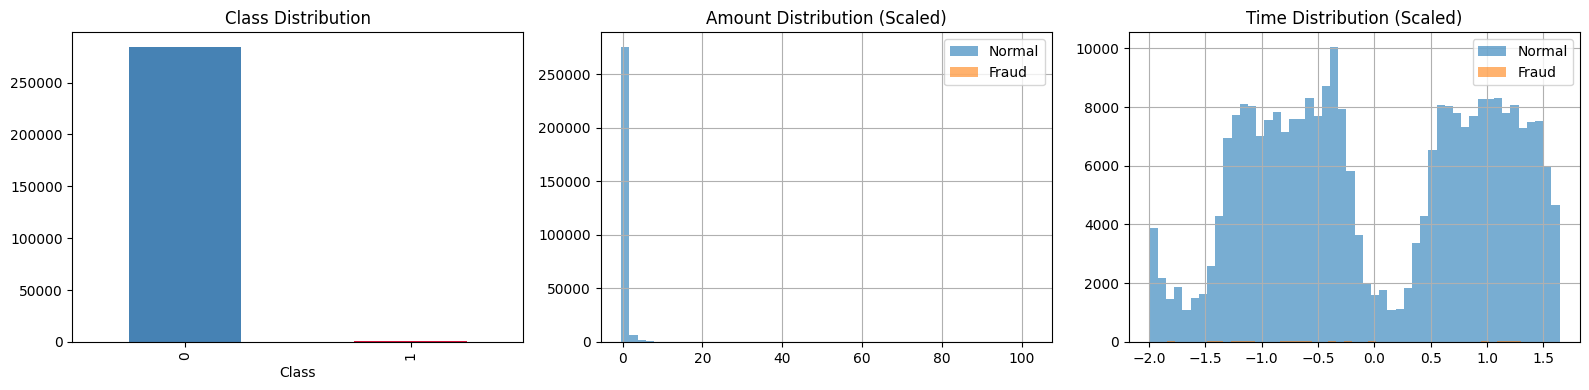

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))


df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','crimson'])
axes[0].set_title('Class Distribution')


df.groupby('Class')['Amount_scaled'].hist(bins=50, ax=axes[1], alpha=0.6)
axes[1].set_title('Amount Distribution (Scaled)')
axes[1].legend(['Normal', 'Fraud'])

df.groupby('Class')['Time_scaled'].hist(bins=50, ax=axes[2], alpha=0.6)
axes[2].set_title('Time Distribution (Scaled)')
axes[2].legend(['Normal', 'Fraud'])

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])
df.drop(['Amount', 'Time'], axis=1, inplace=True)

print(df.shape)
df.head()

(284807, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Time_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
if 'Amount' in df.columns and 'Time' in df.columns:
    df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
    df['Time_scaled'] = scaler.fit_transform(df[['Time']])
    df.drop(['Amount', 'Time'], axis=1, inplace=True)
    print("Amount and Time columns scaled and original columns dropped.")
else:
    print("Amount or Time columns not found. Skipping scaling and dropping as they might have been processed already.")

print(df.shape)
df.head()

Amount or Time columns not found. Skipping scaling and dropping as they might have been processed already.
(284807, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Time_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Önce: {y_train.value_counts().to_dict()}")
print(f"Sonra: {pd.Series(y_train_res).value_counts().to_dict()}")

Önce: {0: 227451, 1: 394}
Sonra: {0: 227451, 1: 227451}


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score


lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred, target_names=['Normal','Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9698
PR-AUC:  0.7249


In [ ]:
import xgboost as xgb


xgb_model = xgb.XGBClassifier(
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
    random_state=42, verbosity=0, eval_metric='aucpr')

xgb_model.fit(X_train_res, y_train_res)

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred, target_names=['Normal','Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.46      0.86      0.60        98

    accuracy                           1.00     56962
   macro avg       0.73      0.93      0.80     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9777
PR-AUC:  0.8418


Optimal Threshold: 0.9996
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.95      0.79      0.86        98

    accuracy                           1.00     56962
   macro avg       0.98      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



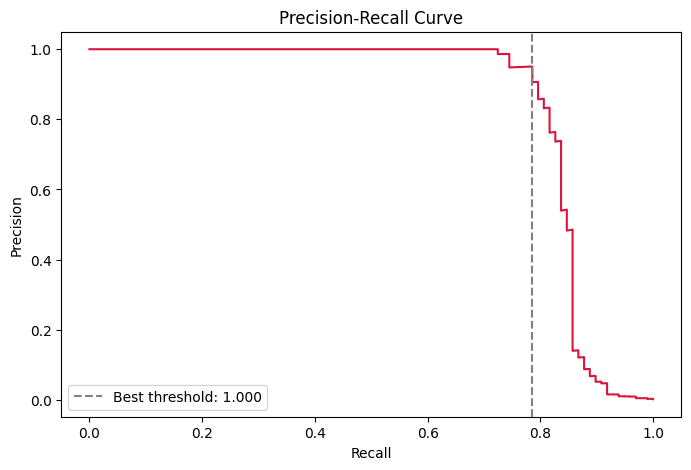

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)


f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold: {best_thresh:.4f}")

y_pred_opt = (y_prob >= best_thresh).astype(int)
print(classification_report(y_test, y_pred_opt, target_names=['Normal','Fraud']))

plt.figure(figsize=(8,5))
plt.plot(recall, precision, color='crimson')
plt.axvline(recall[np.argmax(f1_scores)], color='gray', linestyle='--', label=f'Best threshold: {best_thresh:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

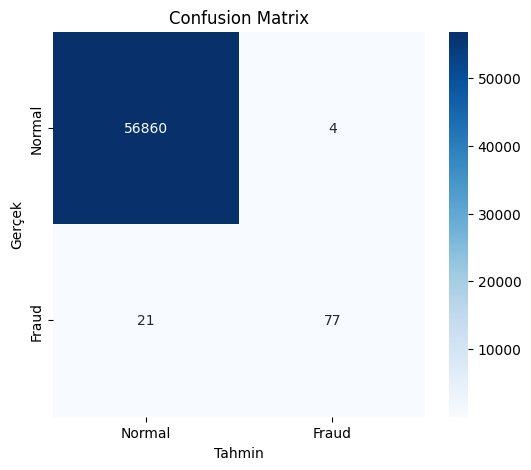

Yakalanan fraud (TP) : 77
Kaçırılan fraud (FN) : 21
Yanlış alarm (FP)    : 4
Toplam hata maliyeti : $2,582
Kurtarılan para      : $9,394


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm.ravel()


plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Fraud'], yticklabels=['Normal','Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.show()


FN_cost = 122
FP_cost = 5
total_cost  = fn * FN_cost + fp * FP_cost
saved       = tp * FN_cost

print(f"Yakalanan fraud (TP) : {tp}")
print(f"Kaçırılan fraud (FN) : {fn}")
print(f"Yanlış alarm (FP)    : {fp}")
print(f"Toplam hata maliyeti : ${total_cost:,.0f}")
print(f"Kurtarılan para      : ${saved:,.0f}")